In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats



# Load Dataset

In [2]:
df=pd.read_csv('Employee Attrition.csv')

In [3]:
df

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left


# 🟢 Level 1 — Basic Data Understanding

In [4]:
# 1 How many rows and columns are present in the dataset?
df
# 59598 rows × 24 columns

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left


In [5]:
# What are the names of all columns?
for col in df.columns:
    print(col)

Employee ID
Age
Gender
Years at Company
Job Role
Monthly Income
Work-Life Balance
Job Satisfaction
Performance Rating
Number of Promotions
Overtime
Distance from Home
Education Level
Marital Status
Number of Dependents
Job Level
Company Size
Company Tenure
Remote Work
Leadership Opportunities
Innovation Opportunities
Company Reputation
Employee Recognition
Attrition


In [6]:
# What are the data types of each column?
df.dtypes

Employee ID                 int64
Age                         int64
Gender                        str
Years at Company            int64
Job Role                      str
Monthly Income              int64
Work-Life Balance             str
Job Satisfaction              str
Performance Rating            str
Number of Promotions        int64
Overtime                      str
Distance from Home          int64
Education Level               str
Marital Status                str
Number of Dependents        int64
Job Level                     str
Company Size                  str
Company Tenure              int64
Remote Work                   str
Leadership Opportunities      str
Innovation Opportunities      str
Company Reputation            str
Employee Recognition          str
Attrition                     str
dtype: object

In [7]:
# Which columns are numerical?
df.select_dtypes(include='number').columns

Index(['Employee ID', 'Age', 'Years at Company', 'Monthly Income',
       'Number of Promotions', 'Distance from Home', 'Number of Dependents',
       'Company Tenure'],
      dtype='str')

In [8]:
# Which columns are categorical?
df.select_dtypes(include='object').columns

C:\Users\MY PC\AppData\Local\Temp\ipykernel_1432\489698153.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Overtime', 'Education Level', 'Marital Status',
       'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='str')

In [9]:
# Which column is the target variable?
# 'Attrition' column are target variable

In [10]:
# What are the unique values of the target variable?
df['Attrition'].value_counts()

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

In [11]:
# What is the shape of the dataset?
df.shape

(59598, 24)

In [12]:
# Are there any missing values?
df.isnull().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [13]:
# Which columns contain missing values?
# not noll value in any column

In [14]:
# Are there any duplicate records?
df.duplicated().sum()

np.int64(0)

In [15]:
# What percentage of the dataset contains duplicates?
duplicate_percentage = df.duplicated().mean()*100
print(duplicate_percentage)

0.0


In [16]:
# How many unique values are present in each categorical column?
for col in df.select_dtypes(include='object').columns:
    print(col,':',df[col].nunique())

Gender : 2
Job Role : 5
Work-Life Balance : 4
Job Satisfaction : 4
Performance Rating : 4
Overtime : 2
Education Level : 5
Marital Status : 3
Job Level : 3
Company Size : 3
Remote Work : 2
Leadership Opportunities : 2
Innovation Opportunities : 2
Company Reputation : 4
Employee Recognition : 4
Attrition : 2


C:\Users\MY PC\AppData\Local\Temp\ipykernel_1432\3088233766.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [17]:
# What is the statistical summary of the numerical variables?
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [18]:
# What is the overall distribution of the target variable?
# 59,598 observations are present in every displayed numerical column → no missing values in these columns.
# Age: 18–59 years, mean ≈ 38.56
# Years at Company: 1–51 years, mean ≈ 15.75
# Monthly Income: ₹1,316–₹16,149, mean ≈ ₹7,302
# Number of Promotions: 0–4, mean ≈ 0.83
# Distance from Home: 1–99, mean ≈ 50.01
# Number of Dependents: 0–6, mean ≈ 1.65
# Company Tenure: 2–128, mean ≈ 55.76

In [19]:
# Is the target variable balanced or imbalanced?
print(df['Attrition'].value_counts())
'''The target variable is fairly balanced, with approximately 52.45% employees 
who stayed and 47.55% employees who left. Therefore, there is no severe class 
imbalance in the target variable.'''

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64


'The target variable is fairly balanced, with approximately 52.45% employees \nwho stayed and 47.55% employees who left. Therefore, there is no severe class \nimbalance in the target variable.'

# 🟢 Level 2 — Univariate Numerical Analysis

In [20]:
# What is the distribution of Age?
df['Age'].describe()

count    59598.000000
mean        38.565875
std         12.079673
min         18.000000
25%         28.000000
50%         39.000000
75%         49.000000
max         59.000000
Name: Age, dtype: float64

In [21]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='str')

In [22]:
# What is the distribution of Monthly Income?
df['Monthly Income'].describe()

count    59598.000000
mean      7302.397983
std       2151.457423
min       1316.000000
25%       5658.000000
50%       7354.000000
75%       8880.000000
max      16149.000000
Name: Monthly Income, dtype: float64

In [23]:
# What is the distribution of Years at Company?
df['Years at Company'].describe()

count    59598.000000
mean        15.753901
std         11.245981
min          1.000000
25%          7.000000
50%         13.000000
75%         23.000000
max         51.000000
Name: Years at Company, dtype: float64

In [24]:
What is the distribution of Distance From Home?
df['Distance from Home'].describe()

Object `Home` not found.


count    59598.000000
mean        50.007651
std         28.466459
min          1.000000
25%         25.000000
50%         50.000000
75%         75.000000
max         99.000000
Name: Distance from Home, dtype: float64

In [25]:
# What is the distribution of Number of Promotions?
df['Number of Promotions'].describe()


count    59598.000000
mean         0.832578
std          0.994991
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: Number of Promotions, dtype: float64

In [26]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='str')

In [27]:
# What is the distribution of Number of Dependents?
df['Number of Dependents'].describe()

count    59598.000000
mean         1.648075
std          1.555689
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max          6.000000
Name: Number of Dependents, dtype: float64

In [28]:
# What is the distribution of Total Working Years?
df['Years at Company'].describe()

count    59598.000000
mean        15.753901
std         11.245981
min          1.000000
25%          7.000000
50%         13.000000
75%         23.000000
max         51.000000
Name: Years at Company, dtype: float64

In [29]:
df.value_counts('Attrition')

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

In [30]:
df.tail()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left
59597,15796,56,Male,19,Technology,6660,Good,High,Average,0,...,3,Mid,Medium,81,No,No,No,Good,Low,Stayed


# Basic DAtaset infortmation

In [31]:
df.shape

(59598, 24)

In [32]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='str')

In [33]:
df.dtypes

Employee ID                 int64
Age                         int64
Gender                        str
Years at Company            int64
Job Role                      str
Monthly Income              int64
Work-Life Balance             str
Job Satisfaction              str
Performance Rating            str
Number of Promotions        int64
Overtime                      str
Distance from Home          int64
Education Level               str
Marital Status                str
Number of Dependents        int64
Job Level                     str
Company Size                  str
Company Tenure              int64
Remote Work                   str
Leadership Opportunities      str
Innovation Opportunities      str
Company Reputation            str
Employee Recognition          str
Attrition                     str
dtype: object

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Employee ID               59598 non-null  int64
 1   Age                       59598 non-null  int64
 2   Gender                    59598 non-null  str  
 3   Years at Company          59598 non-null  int64
 4   Job Role                  59598 non-null  str  
 5   Monthly Income            59598 non-null  int64
 6   Work-Life Balance         59598 non-null  str  
 7   Job Satisfaction          59598 non-null  str  
 8   Performance Rating        59598 non-null  str  
 9   Number of Promotions      59598 non-null  int64
 10  Overtime                  59598 non-null  str  
 11  Distance from Home        59598 non-null  int64
 12  Education Level           59598 non-null  str  
 13  Marital Status            59598 non-null  str  
 14  Number of Dependents      59598 non-null  int64
 

# Statistical summary

In [35]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [36]:
df.describe(include='object')

C:\Users\MY PC\AppData\Local\Temp\ipykernel_1432\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,Job Role,Work-Life Balance,Job Satisfaction,Performance Rating,Overtime,Education Level,Marital Status,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
count,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598
unique,2,5,4,4,4,2,5,3,3,3,2,2,2,4,4,2
top,Male,Technology,Good,High,Average,No,Bachelor’s Degree,Married,Entry,Medium,No,No,No,Good,Low,Stayed
freq,32739,15507,22528,29779,35810,40148,17826,29908,23867,29745,48239,56680,49895,29766,23758,31260


# Number of Unique values

In [37]:
df.nunique().sort_values()

Gender                          2
Overtime                        2
Remote Work                     2
Leadership Opportunities        2
Innovation Opportunities        2
Attrition                       2
Marital Status                  3
Job Level                       3
Company Size                    3
Performance Rating              4
Company Reputation              4
Employee Recognition            4
Work-Life Balance               4
Job Satisfaction                4
Education Level                 5
Job Role                        5
Number of Promotions            5
Number of Dependents            7
Age                            42
Years at Company               51
Distance from Home             99
Company Tenure                127
Monthly Income               9569
Employee ID                 59598
dtype: int64

In [38]:
for col in df.columns:
    print("\n",col)
    print(df[col].unique())


 Employee ID
[ 8410 64756 30257 ... 54887   861 15796]

 Age
[31 59 24 36 56 38 47 48 57 30 29 40 19 33 49 51 39 54 23 45 42 53 37 34
 25 41 55 21 28 26 52 50 27 58 43 35 46 44 20 18 22 32]

 Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

 Years at Company
[19  4 10  7 41  3 23 16 44  1 12  6 38 22 30  9 37 33 13  5 21 32 34 11
  2 18 27 17 36  8 28 35 14 24 40 15 45 39 20 43 26 29 46 42 25 31 47 48
 49 50 51]

 Job Role
<StringArray>
['Education', 'Media', 'Healthcare', 'Technology', 'Finance']
Length: 5, dtype: str

 Monthly Income
[ 5390  5534  8159 ... 12440  2975 12260]

 Work-Life Balance
<StringArray>
['Excellent', 'Poor', 'Good', 'Fair']
Length: 4, dtype: str

 Job Satisfaction
<StringArray>
['Medium', 'High', 'Very High', 'Low']
Length: 4, dtype: str

 Performance Rating
<StringArray>
['Average', 'Low', 'High', 'Below Average']
Length: 4, dtype: str

 Number of Promotions
[2 3 0 1 4]

 Overtime
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 Distance from 

# Missing Values analysis

In [48]:
df.isnull().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [49]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': df.isnull().mean() * 100
})

missing.sort_values('Missing Percentage', ascending=False)

,Missing Values,Missing Percentage
Employee ID,0,0.0
Age,0,0.0
Gender,0,0.0
Years at Company,0,0.0
Job Role,0,0.0
Monthly Income,0,0.0
Work-Life Balance,0,0.0
Job Satisfaction,0,0.0
Performance Rating,0,0.0
Number of Promotions,0,0.0


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
(df.duplicated().sum()/len(df))*100

np.float64(0.0)

In [56]:
for col in df.select_dtypes(include='number'):
    print(f"\nColumn:{col}")
    print("Mean",df[col].mean())
    print("Median",df[col].median())
    print("Minimum",df[col].min())
    print("Maximum",df[col].max())
    print("Standard Daviation",df[col].std())


Column:Employee ID
Mean 37227.1187288164
Median 37209.5
Minimum 1
Maximum 74498
Standard Daviation 21519.150027827032

Column:Age
Mean 38.56587469378167
Median 39.0
Minimum 18
Maximum 59
Standard Daviation 12.07967303066388

Column:Years at Company
Mean 15.753901137622067
Median 13.0
Minimum 1
Maximum 51
Standard Daviation 11.245981298832262

Column:Monthly Income
Mean 7302.397983153797
Median 7354.0
Minimum 1316
Maximum 16149
Standard Daviation 2151.457423002539

Column:Number of Promotions
Mean 0.8325782744387396
Median 1.0
Minimum 0
Maximum 4
Standard Daviation 0.9949911136183586

Column:Distance from Home
Mean 50.00765126346522
Median 50.0
Minimum 1
Maximum 99
Standard Daviation 28.46645898943908

Column:Number of Dependents
Mean 1.6480754387731131
Median 1.0
Minimum 0
Maximum 6
Standard Daviation 1.5556888176132664

Column:Company Tenure
Mean 55.758414711903086
Median 56.0
Minimum 2
Maximum 128
Standard Daviation 25.411089512757616


In [60]:
# Are there any potential outliers?
for col in df.select_dtypes(include='number'):
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f"{col}: {outliers} potential outliers")

Employee ID: 0 potential outliers
Age: 0 potential outliers
Years at Company: 273 potential outliers
Monthly Income: 50 potential outliers
Number of Promotions: 0 potential outliers
Distance from Home: 0 potential outliers
Number of Dependents: 0 potential outliers
Company Tenure: 0 potential outliers


In [62]:
# Is the distribution symmetric or skewed?
for col in df.select_dtypes(include='number'):
    skewness=df[col].skew()
    if abs(skewness)<0.5:
        distribution="Approximately symmetric"
    elif skewness>0:
        distribution="Right -skewed"
    else:
        distribution="Left Skewed"
    print(f"{col}:{distribution}(skewness={skewness:.2f})")    

Employee ID:Approximately symmetric(skewness=0.00)
Age:Approximately symmetric(skewness=-0.01)
Years at Company:Right -skewed(skewness=0.79)
Monthly Income:Approximately symmetric(skewness=0.12)
Number of Promotions:Right -skewed(skewness=0.99)
Distance from Home:Approximately symmetric(skewness=0.00)
Number of Dependents:Right -skewed(skewness=0.72)
Company Tenure:Approximately symmetric(skewness=0.07)


In [65]:
# Which numerical variable has the highest variability?
for col in df.select_dtypes(include='number'):
    print(f"{col}: {df[col].std():2f}")
    

Employee ID: 21519.150028
Age: 12.079673
Years at Company: 11.245981
Monthly Income: 2151.457423
Number of Promotions: 0.994991
Distance from Home: 28.466459
Number of Dependents: 1.555689
Company Tenure: 25.411090


In [69]:
std=df.select_dtypes(include='number').std()
print("Highest Variability:",std.idxmax())

Highest Variability: Employee ID


In [78]:
# Which variable has the most skewed distribution?
skwe=df.select_dtypes(include='number').skew().abs()
print("most skewed variable",skew.idxmax())

most skewed variable Number of Promotions


# 🟡 Level 4 — Target Variable Analysis

In [88]:
# Now focus specifically on Employee Attrition.

# What percentage of employees left the company?
attrition_coont=df['Attrition'].value_counts()
attrition_percentage=df['Attrition'].value_counts(normalize=True)*100

# How many employees left?
print("number of Employee who left:",attrition_coont['Left'])
# How many employees stayed?
print("number of Employee who stayed:",attrition_coont['Stayed'])

# What percentage of employees stayed?
print("percentage of employees who left:",attrition_percentage['Left'])
print("percentage of employee stayed:",attrition_percentage['Stayed'])


# Is the target variable balanced?
'''Employee attrition analysis: the target variable ,attrition, is relatively balanced
in the dataset. out of all employees, 47.55% (5668 employees)left the company , while 
52%(6252 employee) stayed. the difference between the two classes is relatively samll ,
indiccating that there is no severe class imbalance in the target variable.'''

# Is class imbalance likely to affect model performance?

# Which evaluation metrics should be considered besides accuracy?

number of Employee who left: 28338
number of Employee who stayed: 31260
percentage of employees who left: 47.548575455552196
percentage of employee stayed: 52.451424544447804


'Employee attrition analysis: the target variable ,attrition, is relatively balanced\nin the dataset. out of all employees, 47.55% (5668 employees)left the company , while \n52%(6252 employee) stayed. the difference between the two classes is relatively samll ,\nindiccating that there is no severe class imbalance in the target variable.'

# 🟡 Level 5 — Categorical Variables vs Attrition

# For every categorical variable, ask:


In [97]:
from pandas import pivot_table

In [105]:
pivot_table(
    df,
    index='Gender',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count'
)

Attrition,Left,Stayed
Gender,,
Female,14279,12580
Male,14059,18680


In [106]:
# What is the attrition rate by Gender?
gender_pivot = pivot_table(
    df,
    index='Gender',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count'
)

gender_pivot_pct = gender_pivot.div(
    gender_pivot.sum(axis=1),
    axis=0
) * 100

gender_pivot_pct.round(2)

Attrition,Left,Stayed
Gender,,
Female,53.16,46.84
Male,42.94,57.06


In [111]:
# What is the attrition rate by Job Role?
# What is the attrition rate by Work-Life Balance?
# What is the attrition rate by Job Satisfaction?
# What is the attrition rate by Performance Rating?
# What is the attrition rate by Overtime?
# What is the attrition rate by Education Level?
# What is the attrition rate by Marital Status?
# What is the attrition rate by Job Level?
# What is the attrition rate by Company Size?
# What is the attrition rate by Remote Work?
# What is the attrition rate by Leadership Opportunities?
# What is the attrition rate by Innovation Opportunities?
# What is the attrition rate by Company Reputation?
# What is the attrition rate by Employee Recognition?
columns = [
    'Job Role',
    'Work-Life Balance',
    'Job Satisfaction',
    'Performance Rating',
    'Overtime',
    'Education Level',
    'Marital Status',
    'Job Level',
    'Company Size',
    'Remote Work',
    'Leadership Opportunities',
    'Innovation Opportunities',
    'Company Reputation',
    'Employee Recognition'
]

for col in columns:
    print(f"\n{'='*50}")
    print(f"Attrition Rate by {col}")
    print(f"{'='*50}")
    
    pivot = pivot_table(
        df,
        index=col,
        columns='Attrition',
        values='Employee ID',
        aggfunc='count',
        fill_value=0
    )
    
    rate = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    print(rate.round(2))


Attrition Rate by Job Role
Attrition    Left  Stayed
Job Role                 
Education   48.72   51.28
Finance     46.80   53.20
Healthcare  47.31   52.69
Media       47.44   52.56
Technology  47.29   52.71

Attrition Rate by Work-Life Balance
Attrition           Left  Stayed
Work-Life Balance               
Excellent          35.81   64.19
Fair               57.46   42.54
Good               40.56   59.44
Poor               60.11   39.89

Attrition Rate by Job Satisfaction
Attrition          Left  Stayed
Job Satisfaction               
High              45.30   54.70
Low               52.42   47.58
Medium            45.32   54.68
Very High         52.89   47.11

Attrition Rate by Performance Rating
Attrition            Left  Stayed
Performance Rating               
Average             46.15   53.85
Below Average       51.81   48.19
High                46.07   53.93
Low                 57.53   42.47

Attrition Rate by Overtime
Attrition   Left  Stayed
Overtime                
No     

# 🟡 Level 6 — Numerical Variables vs Attrition

In [118]:
# What is the average age of employees who left vs stayed?
print("Average Age:")
print(df.groupby('Attrition')['Age'].mean().round(2))


# What is the median age of employees who left vs stayed?
print("\nMedian Age:")
print(df.groupby('Attrition')['Age'].median().round(2))


# Does Monthly Income differ between employees who left and stayed?
print("\nMonthly Income:")
print(df.groupby('Attrition')['Monthly Income'].mean().round(2))
print(df.groupby('Attrition')['Monthly Income'].median().round(2))


# Does Years at Company differ between the two groups?
print("\nYears at Company:")
print(df.groupby('Attrition')['Years at Company'].mean().round(2))
print(df.groupby('Attrition')['Years at Company'].median().round(2))


# Does Distance From Home differ between the two groups?
print("\nDistance From Home:")
print(df.groupby('Attrition')['Distance from Home'].mean().round(2))
print(df.groupby('Attrition')['Distance from Home'].median().round(2))


# Does Number of Promotions differ between the two groups?
print("\nNumber of Promotions:")
print(df.groupby('Attrition')['Number of Promotions'].mean().round(2))
print(df.groupby('Attrition')['Number of Promotions'].median().round(2))


# Does Number of Dependents differ between the two groups?
print("\nNumber of Dependents:")
print(df.groupby('Attrition')['Number of Dependents'].mean().round(2))
print(df.groupby('Attrition')['Number of Dependents'].median().round(2))





Average Age:
Attrition
Left      37.95
Stayed    39.13
Name: Age, dtype: float64

Median Age:
Attrition
Left      38.0
Stayed    39.0
Name: Age, dtype: float64

Monthly Income:
Attrition
Left      7276.69
Stayed    7325.70
Name: Monthly Income, dtype: float64
Attrition
Left      7321.5
Stayed    7380.0
Name: Monthly Income, dtype: float64

Years at Company:
Attrition
Left      14.99
Stayed    16.45
Name: Years at Company, dtype: float64
Attrition
Left      12.0
Stayed    14.0
Name: Years at Company, dtype: float64

Distance From Home:
Attrition
Left      52.86
Stayed    47.42
Name: Distance from Home, dtype: float64
Attrition
Left      55.0
Stayed    45.0
Name: Distance from Home, dtype: float64

Number of Promotions:
Attrition
Left      0.75
Stayed    0.91
Name: Number of Promotions, dtype: float64
Attrition
Left      0.0
Stayed    1.0
Name: Number of Promotions, dtype: float64

Number of Dependents:
Attrition
Left      1.52
Stayed    1.76
Name: Number of Dependents, dtype: float64
At

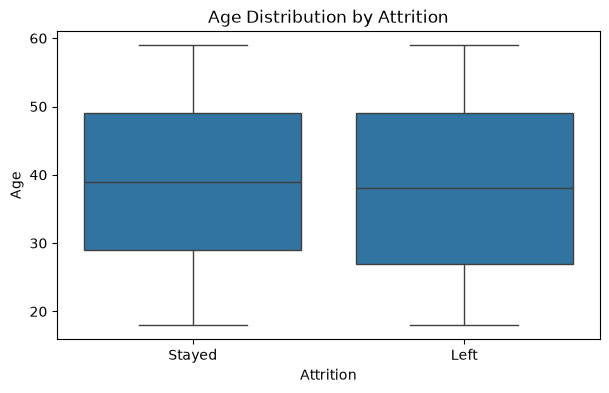

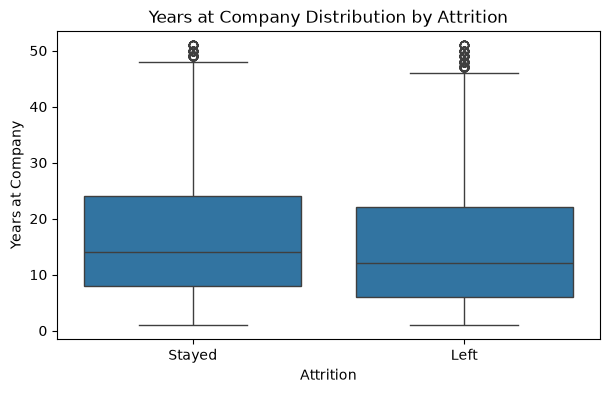

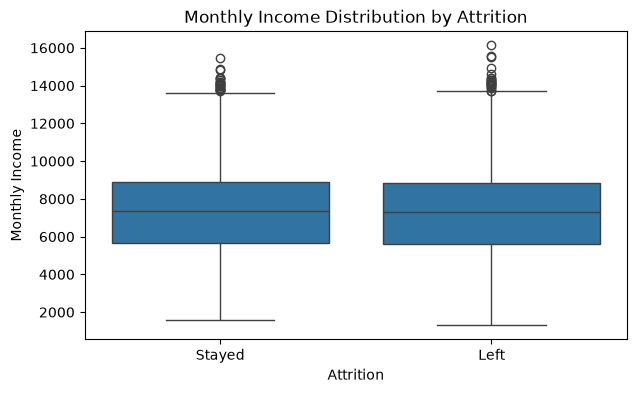

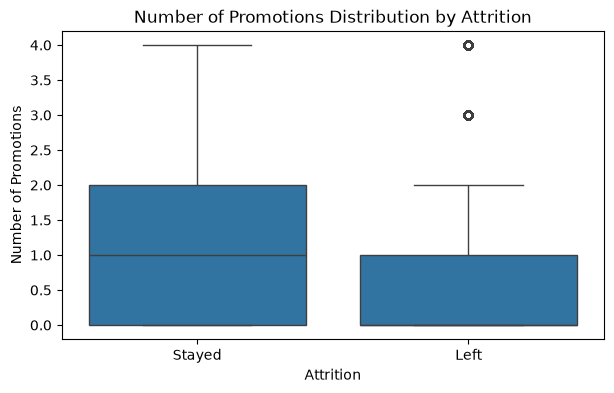

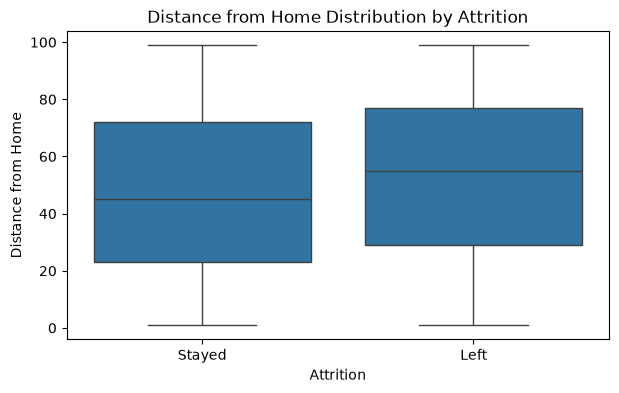

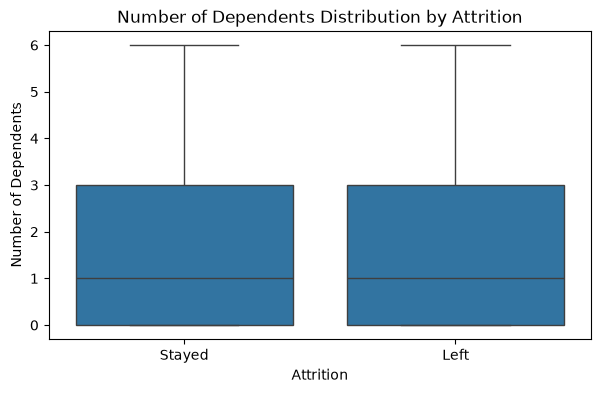

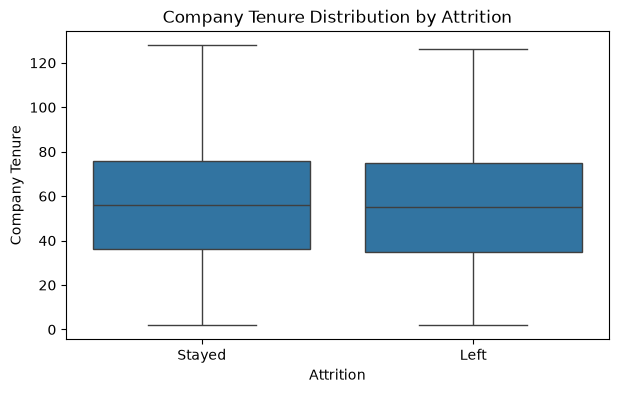

In [119]:
# Are the distributions visually different? 
for col in df.select_dtypes(include='number').drop(columns='Employee ID'):
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x='Attrition', y=col)
    plt.title(f'{col} Distribution by Attrition')
    plt.show()

In [121]:
# 4.  Are there more outliers in one attrition group? 
for col in df.select_dtypes(include='number').drop(columns='Employee ID'):
    
    print(f"\n{col}")
    
    for group in ['Left', 'Stayed']:
        
        data = df[df['Attrition'] == group][col]
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = ((data < lower) | (data > upper)).sum()
        
        print(f"{group}: {outliers} potential outliers")


Age
Left: 0 potential outliers
Stayed: 0 potential outliers

Years at Company
Left: 175 potential outliers
Stayed: 98 potential outliers

Monthly Income
Left: 24 potential outliers
Stayed: 25 potential outliers

Number of Promotions
Left: 1003 potential outliers
Stayed: 0 potential outliers

Distance from Home
Left: 0 potential outliers
Stayed: 0 potential outliers

Number of Dependents
Left: 0 potential outliers
Stayed: 0 potential outliers

Company Tenure
Left: 0 potential outliers
Stayed: 0 potential outliers


In [126]:
# Which age group has the highest attrition rate?

In [127]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [135]:
age_pivot = pivot_table(
    df,
    index='Age Group',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

age_rate = (age_pivot['Left'] / age_pivot.sum(axis=1) * 100).round(2)

print(age_rate)
print("Highest:", age_rate.idxmax(), age_rate.max(), "%")
# Which age group has the lowest attrition rate?
print("lowest:", age_rate.idxmin(), age_rate.min(), "%")

Age Group
18-25    53.19
26-35    47.86
36-45    45.09
46-55    46.23
56-65    45.09
dtype: float64
Highest: 18-25 53.19 %
lowest: 36-45 45.09 %


In [133]:
# Does attrition vary significantly across different age groups?
age_pivot = pivot_table(
    df,
    index='Age Group',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

age_rate = (
    age_pivot['Left'] /
    age_pivot.sum(axis=1) * 100
).round(2)

print(age_rate)

Age Group
18-25    53.19
26-35    47.86
36-45    45.09
46-55    46.23
56-65    45.09
dtype: float64


In [136]:
# Is there a particular age group that is more likely to leave the company?


print(
    "Age group more likely to leave:",
    age_rate.idxmax(),
    age_rate.max(),
    "%"
)

Age group more likely to leave: 18-25 53.19 %


In [137]:
# What is the attrition rate by gender?
# What is the attrition rate by Gender?

gender_pivot = pivot_table(
    df,
    index='Gender',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

gender_rate = (
    gender_pivot['Left'] /
    gender_pivot.sum(axis=1) * 100
).round(2)

print(gender_rate)

Gender
Female    53.16
Male      42.94
dtype: float64


In [ ]:
Which gender has the highest attrition rate?
Female employees have the highest attrition rate, at 53.16%, compared with 42.94% for male employees.


In [ ]:
Does marital status have an impact on employee attrition?
Yes, the attrition rate varies across different marital-status categories, suggesting that marital status may be associated with employee attrition. However, this does not prove a statistically significant relationship. A Chi-Square test would be required to confirm the association.


In [138]:
# Which marital-status category has the highest attrition?
marital_pivot = pivot_table(
    df,
    index='Marital Status',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

marital_rate = (
    marital_pivot['Left'] /
    marital_pivot.sum(axis=1) * 100
).round(2)

print(marital_rate)

print(
    "\nHighest attrition:",
    marital_rate.idxmax(),
    marital_rate.max(),
    "%"
)

Marital Status
Divorced    40.70
Married     36.15
Single      66.83
dtype: float64

Highest attrition: Single 66.83 %


In [149]:
# Which job role has the highest attrition rate?
job_role_pivot = pivot_table(
    df,
    index='Job Role',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

job_role_rate = (
    job_role_pivot['Left'] /
    job_role_pivot.sum(axis=1) * 100
).round(2)

print(job_role_rate)

print(
    "The Education job role has the highest attrition rate:",
    job_role_rate.idxmax(),
    job_role_rate.max(),
    "%"
)

Job Role
Education     48.72
Finance       46.80
Healthcare    47.31
Media         47.44
Technology    47.29
dtype: float64
The Education job role has the highest attrition rate: Education 48.72 %


In [150]:
# Which job role has the lowest attrition rate?
print(
    "The Finance job role has the lowest attrition rate:",
    job_role_rate.idxmin(),
    job_role_rate.min(),
    "%"
)


The Finance job role has the lowest attrition rate: Finance 46.8 %


In [151]:
# Does job level influence employee attrition?

job_level_pivot = pivot_table(
    df,
    index='Job Level',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

job_level_rate = (
    job_level_pivot['Left'] /
    job_level_pivot.sum(axis=1) * 100
).round(2)

print(job_level_rate)


Job Level
Entry     63.19
Mid       45.56
Senior    20.31
dtype: float64


In [ ]:
# Which job level has the highest attrition?
The Entry job level has the highest attrition rate at 63.19%.

In [153]:
bins = [0, 5, 10, 15, 20, 50]
labels = ['0-5', '6-10', '11-15', '16-20', '21+']

df['Years at Company Group'] = pd.cut(
    df['Years at Company'],
    bins=bins,
    labels=labels
)

In [154]:
# Do employees with fewer years at the company have higher attrition?

years_pivot = pivot_table(
    df,
    index='Years at Company Group',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

years_rate = (
    years_pivot['Left'] /
    years_pivot.sum(axis=1) * 100
).round(2)

print(years_rate)

Years at Company Group
0-5      53.20
6-10     51.57
11-15    45.21
16-20    44.07
21+      43.91
dtype: float64


In [158]:
bins = [0, 25, 50, 75, 100, 150]
labels = ['0-25', '26-50', '51-75', '76-100', '101+']

df['Company Tenure Group'] = pd.cut(
    df['Company Tenure'],
    bins=bins,
    labels=labels
)

In [159]:
tenure_pivot = pivot_table(
    df,
    index='Company Tenure Group',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

tenure_rate = (
    tenure_pivot['Left'] /
    tenure_pivot.sum(axis=1) * 100
).round(2)

print(tenure_rate)

Company Tenure Group
0-25      50.58
26-50     47.75
51-75     47.62
76-100    45.76
101+      44.21
dtype: float64


In [ ]:
# Which experience group has the highest attrition?
# The 0–25 years Company Tenure group has the highest attrition rate, at 50.58%.

In [160]:
# Does Monthly Income differ significantly between employees who left and stayed?

from scipy.stats import ttest_ind

left_income = df[df['Attrition'] == 'Left']['Monthly Income']
stayed_income = df[df['Attrition'] == 'Stayed']['Monthly Income']

t_stat, p_value = ttest_ind(
    left_income,
    stayed_income,
    equal_var=False
)

print("Left Mean:", left_income.mean().round(2))
print("Stayed Mean:", stayed_income.mean().round(2))
print("t-statistic:", round(t_stat, 2))
print("p-value:", p_value)

Left Mean: 7276.69
Stayed Mean: 7325.7
t-statistic: -2.78
p-value: 0.00550018744852805


In [161]:
if p_value < 0.05:
    print("Monthly Income differs significantly between employees who left and stayed.")
else:
    print("Monthly Income does not differ significantly between employees who left and stayed.")

Monthly Income differs significantly between employees who left and stayed.


In [163]:
# Which income group has the highest attrition?

bins = [0, 3000, 5000, 7500, 10000, df['Monthly Income'].max()]
labels = ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']

df['Income Group'] = pd.cut(
    df['Monthly Income'],
    bins=bins,
    labels=labels,
    include_lowest=True
)


income_pivot = pivot_table(
    df,
    index='Income Group',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

income_rate = (
    income_pivot['Left'] /
    income_pivot.sum(axis=1) * 100
).round(2)

print(income_rate)

print(
    "Highest attrition:",
    income_rate.idxmax(),
    income_rate.max(),
    "%"
)

Income Group
Low             50.72
Lower-Middle    49.22
Middle          47.21
Upper-Middle    47.25
High            47.07
dtype: float64
Highest attrition: Low 50.72 %


In [164]:
# Does the number of promotions affect employee attrition?


promotion_pivot = pivot_table(
    df,
    index='Number of Promotions',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

promotion_rate = (
    promotion_pivot['Left'] /
    promotion_pivot.sum(axis=1) * 100
).round(2)

print(promotion_rate)

Number of Promotions
0    49.33
1    49.02
2    49.07
3    25.36
4    22.84
dtype: float64


# Employee Satisfaction & Work Environment


In [165]:
# Which job satisfaction level has the highest attrition?
# Which job satisfaction level has the highest attrition?

satisfaction_pivot = pivot_table(
    df,
    index='Job Satisfaction',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

satisfaction_rate = (
    satisfaction_pivot['Left'] /
    satisfaction_pivot.sum(axis=1) * 100
).round(2)

print(satisfaction_rate)

print(
    "Highest attrition:",
    satisfaction_rate.idxmax(),
    satisfaction_rate.max(),
    "%"
)

Job Satisfaction
High         45.30
Low          52.42
Medium       45.32
Very High    52.89
dtype: float64
Highest attrition: Very High 52.89 %


In [ ]:
# The Very High Job Satisfaction group has the highest attrition rate at 52.89%.

In [166]:
# Does work-life balance affect employee attrition?

worklife_pivot = pivot_table(
    df,
    index='Work-Life Balance',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

worklife_rate = (
    worklife_pivot['Left'] /
    worklife_pivot.sum(axis=1) * 100
).round(2)

print(worklife_rate)

Work-Life Balance
Excellent    35.81
Fair         57.46
Good         40.56
Poor         60.11
dtype: float64


In [ ]:
# Which work-life balance category has the highest attrition?
# The Poor Work-Life Balance category has the highest attrition rate at 60.11%.

In [167]:
# Does employee recognition influence attrition?

recognition_pivot = pivot_table(
    df,
    index='Employee Recognition',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

recognition_rate = (
    recognition_pivot['Left'] /
    recognition_pivot.sum(axis=1) * 100
).round(2)

print(recognition_rate)

Employee Recognition
High         47.18
Low          47.83
Medium       47.71
Very High    46.14
dtype: float64


In [ ]:
# Which recognition level has the highest attrition?
# The Low Employee Recognition level has the highest attrition rate at 47.83%.

In [168]:
# Does overtime increase employee attrition?

overtime_pivot = pivot_table(
    df,
    index='Overtime',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

overtime_rate = (
    overtime_pivot['Left'] /
    overtime_pivot.sum(axis=1) * 100
).round(2)

print(overtime_rate)

Overtime
No     45.61
Yes    51.54
dtype: float64


In [ ]:
# What is the attrition rate among employees who work overtime?
# Employees who work overtime have an attrition rate of 51.54%.

In [169]:
# Does remote work affect employee attrition?

remote_pivot = pivot_table(
    df,
    index='Remote Work',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

remote_rate = (
    remote_pivot['Left'] /
    remote_pivot.sum(axis=1) * 100
).round(2)

print(remote_rate)

Remote Work
No     52.89
Yes    24.86
dtype: float64


# 🎓 Education

In [170]:
# Which education level has the highest attrition?

education_pivot = pivot_table(
    df,
    index='Education Level',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

education_rate = (
    education_pivot['Left'] /
    education_pivot.sum(axis=1) * 100
).round(2)

print(education_rate)

print(
    "Highest attrition:",
    education_rate.idxmax(),
    education_rate.max(),
    "%"
)

Education Level
Associate Degree     48.47
Bachelor’s Degree    49.32
High School          48.25
Master’s Degree      48.93
PhD                  24.86
dtype: float64
Highest attrition: Bachelor’s Degree 49.32 %


In [ ]:
# The Bachelor’s Degree education level has the highest attrition rate, at 49.32%.

In [171]:
# Are high attrition rates in any education category based on a small sample?

education_count = df['Education Level'].value_counts()

education_summary = pd.DataFrame({
    'Employee Count': education_count,
    'Attrition Rate (%)': education_rate
})

print(education_summary.sort_values(
    'Attrition Rate (%)',
    ascending=False
))

                   Employee Count  Attrition Rate (%)
Education Level                                      
Bachelor’s Degree           17826               49.32
Master’s Degree             12020               48.93
Associate Degree            14915               48.47
High School                 11748               48.25
PhD                          3089               24.86


# 🏢 Company & Opportunities


In [172]:
# Does company size affect employee attrition?

company_size_pivot = pivot_table(
    df,
    index='Company Size',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

company_size_rate = (
    company_size_pivot['Left'] /
    company_size_pivot.sum(axis=1) * 100
).round(2)

print(company_size_rate)

Object `attrition` not found.
Company Size
Large     46.47
Medium    46.58
Small     49.87
dtype: float64


In [ ]:
# Which company-size category has the highest attrition?
# The Small company-size category has the highest attrition rate at 49.87%.

In [173]:
# Does company reputation influence employee attrition?

reputation_pivot = pivot_table(
    df,
    index='Company Reputation',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

reputation_rate = (
    reputation_pivot['Left'] /
    reputation_pivot.sum(axis=1) * 100
).round(2)

print(reputation_rate)

Company Reputation
Excellent    43.92
Fair         51.94
Good         42.91
Poor         56.50
dtype: float64


In [ ]:
# Which company-reputation category has the highest attrition?
# The “Poor” company reputation category has the highest attrition rate, at 56.50%.

In [174]:
# Do leadership opportunities affect employee attrition?

leadership_pivot = pivot_table(
    df,
    index='Leadership Opportunities',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

leadership_rate = (
    leadership_pivot['Left'] /
    leadership_pivot.sum(axis=1) * 100
).round(2)

print(leadership_rate)

Leadership Opportunities
No     47.66
Yes    45.31
dtype: float64


In [175]:
# Do innovation opportunities influence employee attrition?


innovation_pivot = pivot_table(
    df,
    index='Innovation Opportunities',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

innovation_rate = (
    innovation_pivot['Left'] /
    innovation_pivot.sum(axis=1) * 100
).round(2)

print(innovation_rate)

Innovation Opportunities
No     48.02
Yes    45.11
dtype: float64


# Deeper / High-Level Questions

In [176]:
# Which feature shows the largest difference in attrition rate between its categories?

features = [
    'Gender',
    'Job Role',
    'Work-Life Balance',
    'Job Satisfaction',
    'Performance Rating',
    'Overtime',
    'Education Level',
    'Marital Status',
    'Job Level',
    'Company Size',
    'Remote Work',
    'Leadership Opportunities',
    'Innovation Opportunities',
    'Company Reputation',
    'Employee Recognition'
]

for feature in features:
    pivot = pivot_table(
        df,
        index=feature,
        columns='Attrition',
        values='Employee ID',
        aggfunc='count',
        fill_value=0
    )

    rate = (pivot['Left'] / pivot.sum(axis=1) * 100).round(2)

    difference = rate.max() - rate.min()

    print(f"{feature}: {difference:.2f}%")

Gender: 10.22%
Job Role: 1.92%
Work-Life Balance: 24.30%
Job Satisfaction: 7.59%
Performance Rating: 11.46%
Overtime: 5.93%
Education Level: 24.46%
Marital Status: 30.68%
Job Level: 42.88%
Company Size: 3.40%
Remote Work: 28.03%
Leadership Opportunities: 2.35%
Innovation Opportunities: 2.91%
Company Reputation: 13.59%
Employee Recognition: 1.69%


In [177]:
differences = {}

for feature in features:
    pivot = pivot_table(
        df,
        index=feature,
        columns='Attrition',
        values='Employee ID',
        aggfunc='count',
        fill_value=0
    )

    rate = pivot['Left'] / pivot.sum(axis=1) * 100
    differences[feature] = rate.max() - rate.min()

largest_feature = max(differences, key=differences.get)

print(
    "Feature with largest attrition difference:",
    largest_feature,
    round(differences[largest_feature], 2),
    "%"
)

Feature with largest attrition difference: Job Level 42.88 %


In [178]:
# Are younger employees more likely to leave?

age_pivot = pivot_table(
    df,
    index='Age Group',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

age_rate = (
    age_pivot['Left'] /
    age_pivot.sum(axis=1) * 100
).round(2)

print(age_rate)

Age Group
18-25    53.19
26-35    47.86
36-45    45.09
46-55    46.23
56-65    45.09
dtype: float64


In [180]:
# Which combination of factors appears to be associated with the highest attrition?

combo_pivot = pivot_table(
    df,
    index=['Job Level', 'Overtime', 'Work-Life Balance'],
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

combo_rate = (
    combo_pivot['Left'] /
    combo_pivot.sum(axis=1) * 100
).round(2)

print(combo_rate.sort_values(ascending=False).head(10))

Job Level  Overtime  Work-Life Balance
Entry      Yes       Poor                 80.16
                     Fair                 76.34
           No        Poor                 73.32
                     Fair                 70.95
Mid        Yes       Poor                 65.17
Entry      Yes       Good                 60.19
Mid        Yes       Fair                 59.71
           No        Poor                 57.01
Entry      Yes       Excellent            55.87
           No        Good                 54.90
dtype: float64


# Numerical Relationships

In [181]:
# What is the relationship between Age and Monthly Income?

correlation = df['Age'].corr(df['Monthly Income'])

print("Correlation between Age and Monthly Income:", round(correlation, 2))

Correlation between Age and Monthly Income: -0.0


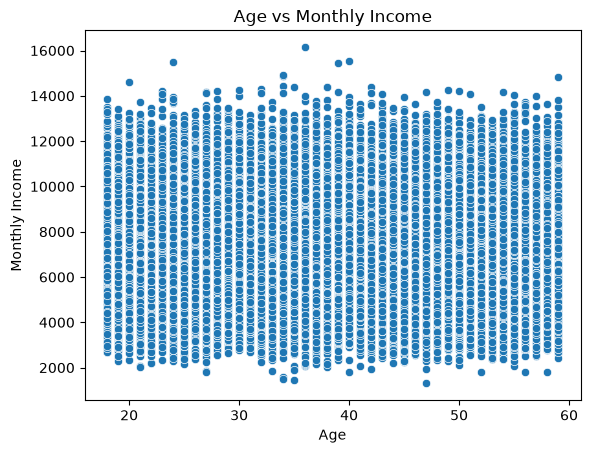

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df,
    x='Age',
    y='Monthly Income'
)

plt.title('Age vs Monthly Income')
plt.xlabel('Age')
plt.ylabel('Monthly Income')
plt.show()

In [183]:
# What is the relationship between Age and Years at Company?

correlation = df['Age'].corr(df['Years at Company'])

print("Correlation between Age and Years at Company:", round(correlation, 2))

Correlation between Age and Years at Company: 0.54


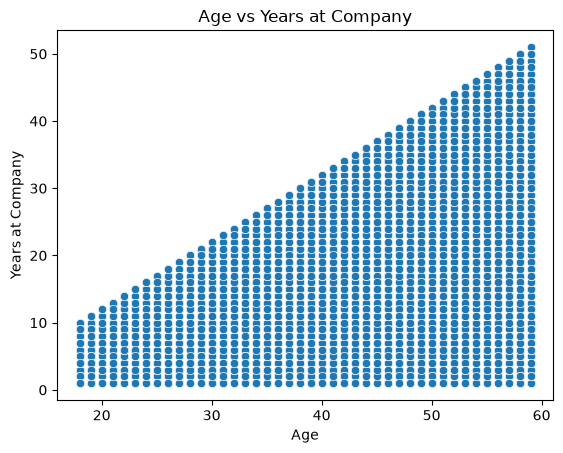

In [184]:
sns.scatterplot(
    data=df,
    x='Age',
    y='Years at Company'
)

plt.title('Age vs Years at Company')
plt.xlabel('Age')
plt.ylabel('Years at Company')
plt.show()

In [185]:
# What is the relationship between Years at Company and Monthly Income?

correlation = df['Years at Company'].corr(df['Monthly Income'])

print(
    "Correlation between Years at Company and Monthly Income:",
    round(correlation, 2)
)

Correlation between Years at Company and Monthly Income: -0.01


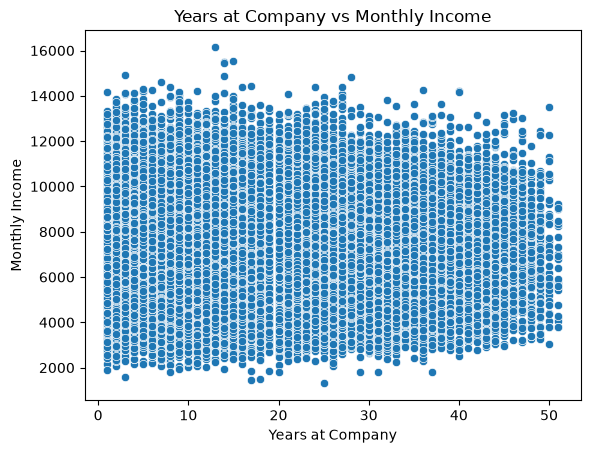

In [186]:
sns.scatterplot(
    data=df,
    x='Years at Company',
    y='Monthly Income'
)

plt.title('Years at Company vs Monthly Income')
plt.xlabel('Years at Company')
plt.ylabel('Monthly Income')
plt.show()

In [187]:
# What is the relationship between Number of Promotions and Years at Company?

correlation = df['Number of Promotions'].corr(df['Years at Company'])

print(
    "Correlation between Number of Promotions and Years at Company:",
    round(correlation, 2)
)

Correlation between Number of Promotions and Years at Company: -0.0


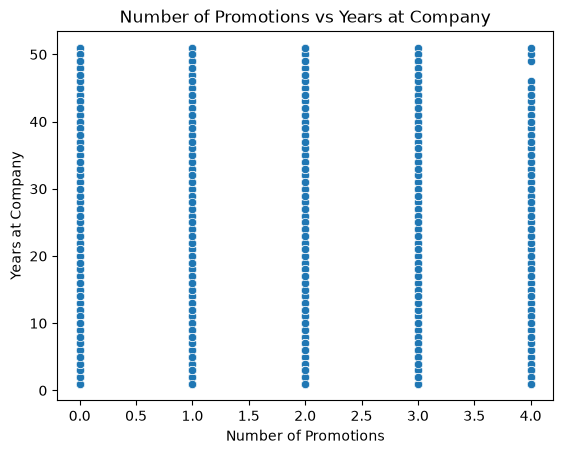

In [188]:
sns.scatterplot(
    data=df,
    x='Number of Promotions',
    y='Years at Company'
)

plt.title('Number of Promotions vs Years at Company')
plt.xlabel('Number of Promotions')
plt.ylabel('Years at Company')
plt.show()

In [189]:
# Create Distance from Home groups

bins = [0, 5, 10, 20, 30, float('inf')]
labels = ['0-5', '6-10', '11-20', '21-30', '31+']

df['Distance Group'] = pd.cut(
    df['Distance from Home'],
    bins=bins,
    labels=labels
)

In [190]:
# Distance from Home vs Attrition

distance_pivot = pivot_table(
    df,
    index='Distance Group',
    columns='Attrition',
    values='Employee ID',
    aggfunc='count',
    fill_value=0
)

distance_rate = (
    distance_pivot['Left'] /
    distance_pivot.sum(axis=1) * 100
).round(2)

print(distance_rate)

Distance Group
0-5      42.19
6-10     41.70
11-20    41.53
21-30    42.74
31+      49.91
dtype: float64


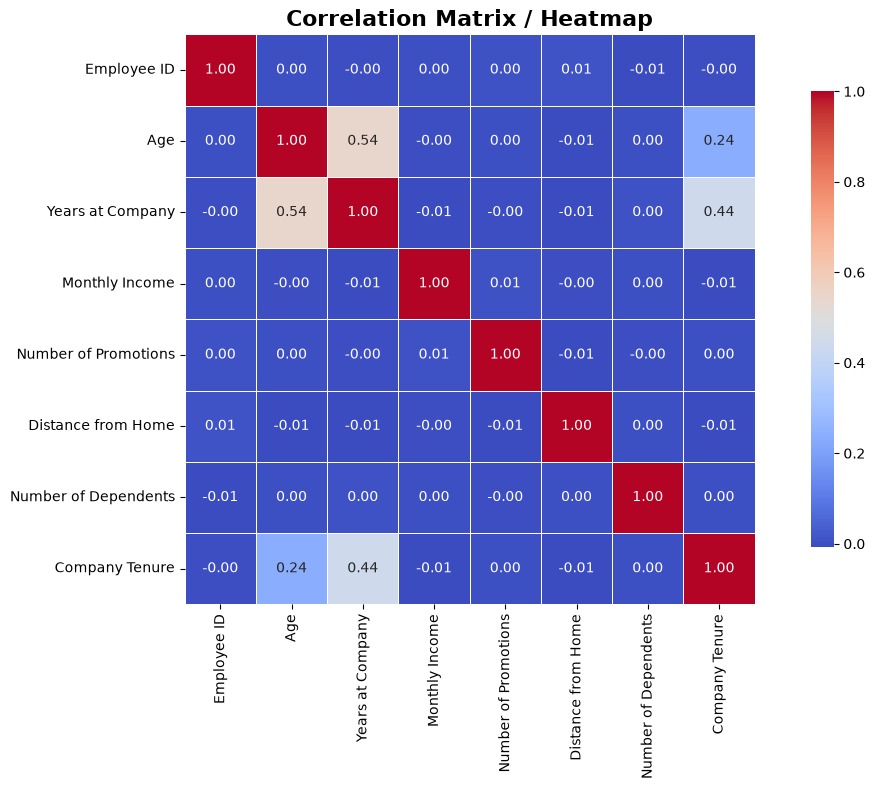

In [194]:
# Correlation Matrix / Heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix / Heatmap', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# Categorical Relationships

In [196]:
# Job Satisfaction vs Work-Life Balance

satisfaction_wlb = pd.crosstab(
    df['Job Satisfaction'],
    df['Work-Life Balance'],
    normalize='index'
) * 100

print(satisfaction_wlb.round(2))

Work-Life Balance  Excellent   Fair   Good   Poor
Job Satisfaction                                 
High                   17.65  30.39  37.83  14.12
Low                    19.01  30.54  37.07  13.38
Medium                 18.27  29.65  38.11  13.96
Very High              18.02  30.49  37.77  13.71


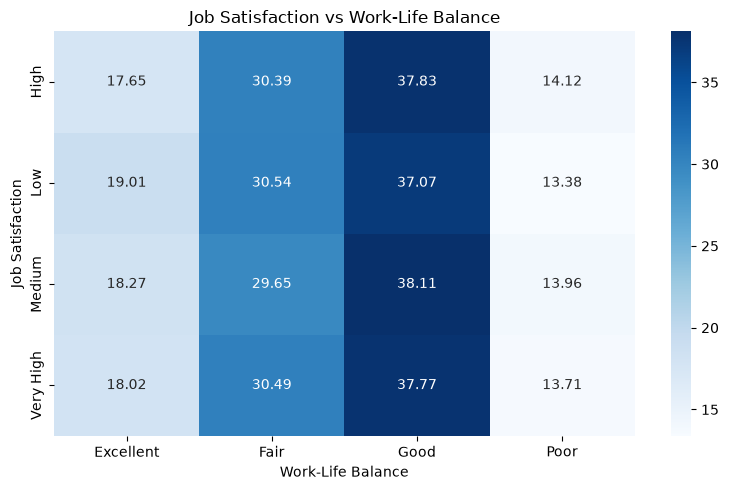

In [197]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    satisfaction_wlb,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Job Satisfaction vs Work-Life Balance')
plt.xlabel('Work-Life Balance')
plt.ylabel('Job Satisfaction')
plt.tight_layout()
plt.show()

In [198]:
# Job Satisfaction vs Performance Rating

satisfaction_performance = pd.crosstab(
    df['Job Satisfaction'],
    df['Performance Rating'],
    normalize='index'
) * 100

print(satisfaction_performance.round(2))

Performance Rating  Average  Below Average   High   Low
Job Satisfaction                                       
High                  59.96          15.02  20.01  5.02
Low                   59.99          15.33  19.81  4.87
Medium                60.67          14.80  19.70  4.83
Very High             59.88          15.08  20.11  4.94


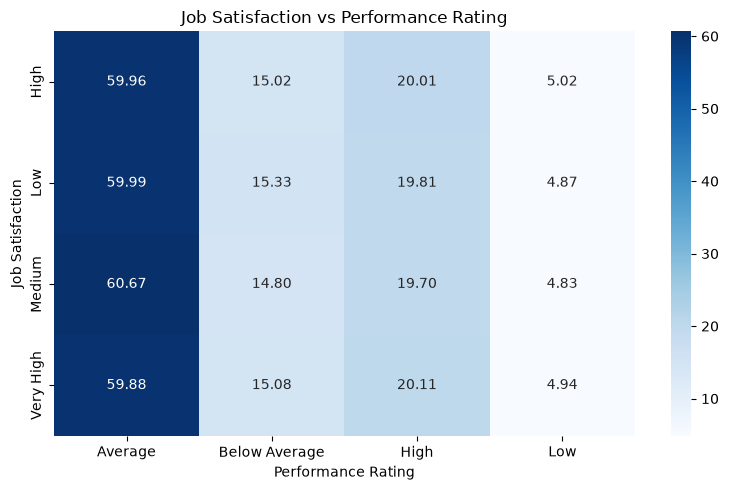

In [199]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    satisfaction_performance,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Job Satisfaction vs Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Job Satisfaction')
plt.tight_layout()
plt.show()

In [200]:
# Employee Recognition vs Job Satisfaction

recognition_satisfaction = pd.crosstab(
    df['Employee Recognition'],
    df['Job Satisfaction'],
    normalize='index'
) * 100

print(recognition_satisfaction.round(2))

Job Satisfaction       High    Low  Medium  Very High
Employee Recognition                                 
High                  50.11   9.72   19.52      20.65
Low                   50.32   9.87   19.70      20.11
Medium                49.58  10.08   20.26      20.09
Very High             48.80   9.58   19.81      21.80


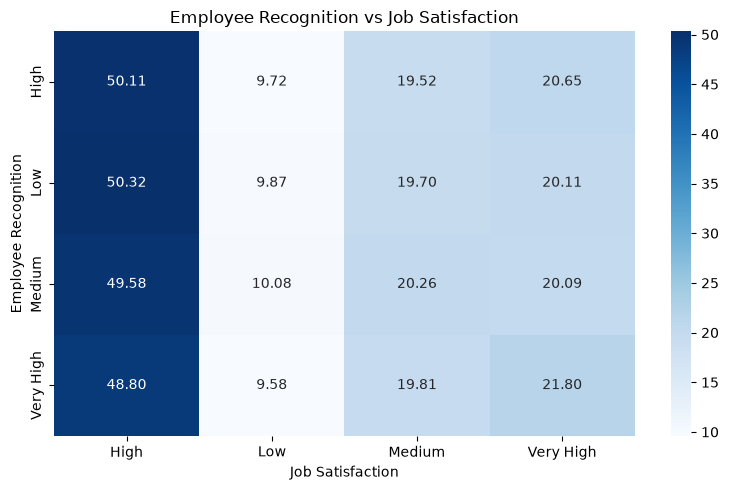

In [201]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    recognition_satisfaction,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Employee Recognition vs Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Employee Recognition')
plt.tight_layout()
plt.show()

In [202]:
# Remote Work vs Work-Life Balance

remote_wlb = pd.crosstab(
    df['Remote Work'],
    df['Work-Life Balance'],
    normalize='index'
) * 100

print(remote_wlb.round(2))

Work-Life Balance  Excellent   Fair   Good   Poor
Remote Work                                      
No                     17.94  30.26  37.88  13.92
Yes                    18.19  30.36  37.44  14.01


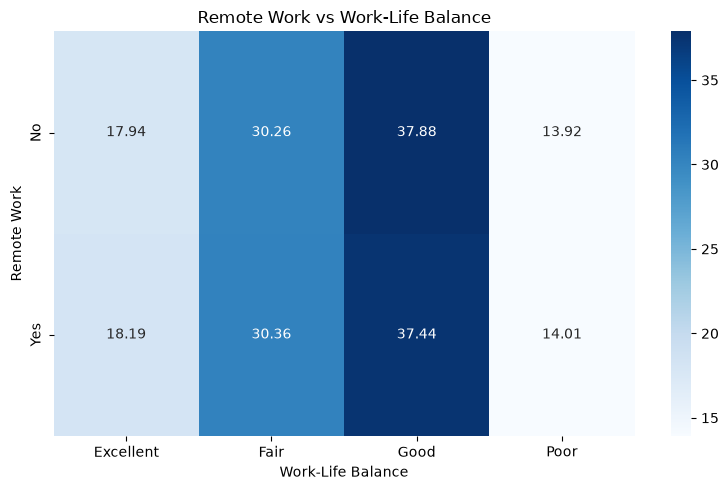

In [203]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    remote_wlb,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Remote Work vs Work-Life Balance')
plt.xlabel('Work-Life Balance')
plt.ylabel('Remote Work')
plt.tight_layout()
plt.show()

In [ ]:
# Overtime vs Work-Life Balance
| Work-Life Balance | Remote = No | Remote = Yes |
| ----------------- | ----------: | -----------: |
| Excellent         |      17.94% |       18.19% |
| Fair              |      30.26% |       30.36% |
| Good              |      37.88% |       37.44% |
| Poor              |      13.92% |       14.01% |


In [204]:
# Leadership Opportunities vs Job Level

leadership_joblevel = pd.crosstab(
    df['Leadership Opportunities'],
    df['Job Level'],
    normalize='index'
) * 100

print(leadership_joblevel.round(2))

Job Level                 Entry    Mid  Senior
Leadership Opportunities                      
No                        40.01  39.89   20.10
Yes                       40.85  39.10   20.05


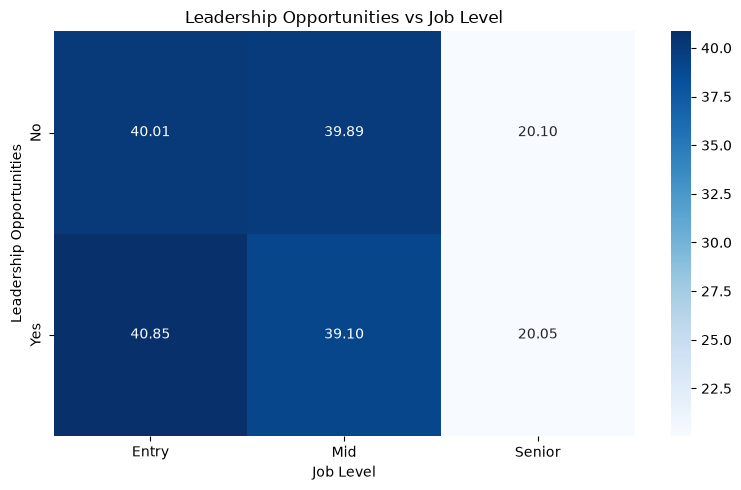

In [205]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    leadership_joblevel,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Leadership Opportunities vs Job Level')
plt.xlabel('Job Level')
plt.ylabel('Leadership Opportunities')
plt.tight_layout()
plt.show()

In [ ]:
Innovation Opportunities vs Job Role

In [206]:
# Innovation Opportunities vs Job Role

innovation_jobrole = pd.crosstab(
    df['Innovation Opportunities'],
    df['Job Role'],
    normalize='index'
) * 100

print(innovation_jobrole.round(2))

Job Role                  Education  Finance  Healthcare  Media  Technology
Innovation Opportunities                                                   
No                            20.89    14.07       22.96  16.09       26.00
Yes                           21.31    14.08       22.54  15.93       26.14


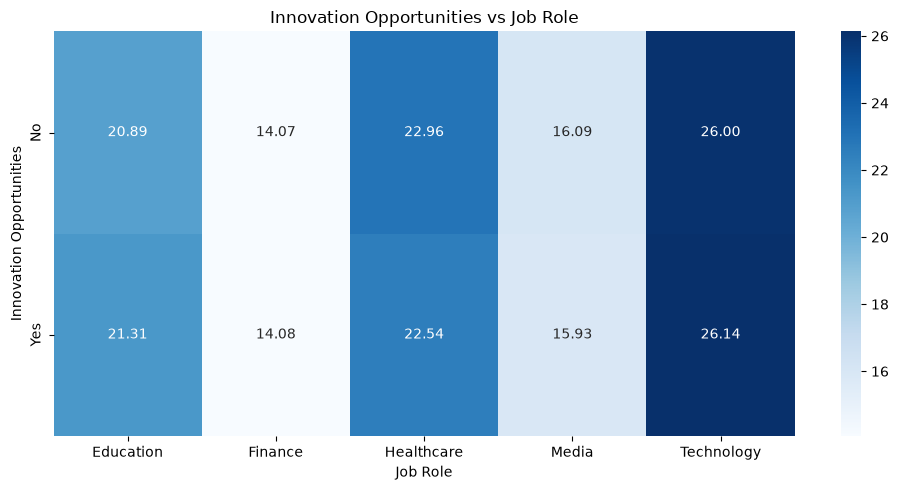

In [207]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    innovation_jobrole,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Innovation Opportunities vs Job Role')
plt.xlabel('Job Role')
plt.ylabel('Innovation Opportunities')
plt.tight_layout()
plt.show()